In [1]:
from google.colab import files
uploaded = files.upload()

Saving Cuplikan layar 2026-02-05 090548.png to Cuplikan layar 2026-02-05 090548.png


Kode ini berfungsi untuk mengupload foto yang akan diproses nantinya.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Libraries di atas dipakai untuk pengolahan citra.

1. Library OpenCV (cv2) digunakan untuk membaca dan memproses citra digital, seperti melakukan konversi dari citra berwarna (RGB) menjadi citra grayscale serta mengakses nilai piksel pada setiap koordinat.
2. NumPy (np) digunakan untuk menangani operasi numerik dan manipulasi array, karena citra digital direpresentasikan dalam bentuk matriks dua dimensi (atau tiga dimensi untuk citra berwarna). Dengan NumPy, kita dapat membuat array kosong untuk menyimpan hasil pemrosesan serta mengatur tipe data piksel.
3. Matplotlib (plt) digunakan untuk menampilkan citra hasil pemrosesan ke dalam bentuk visual sehingga dapat dibandingkan antara citra asli, citra hasil penjumlahan skalar, dan citra hasil pengurangan skalar.

(np.float64(-0.5), np.float64(590.5), np.float64(418.5), np.float64(-0.5))

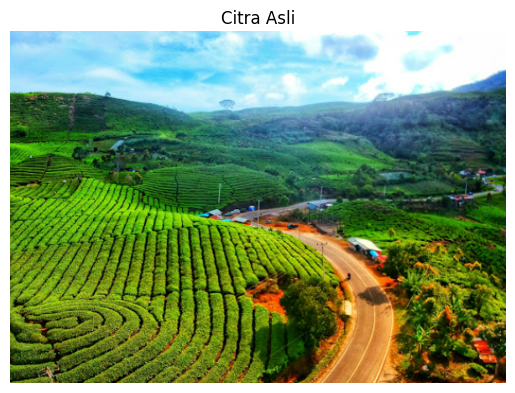

In [20]:
img = cv2.imread('Cuplikan layar 2026-02-05 090548.png')

# Konversi BGR ke RGB (supaya warna tidak aneh)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis('off')

Pada tahap ini, citra dibaca menggunakan fungsi cv2.imread() dari library OpenCV dengan memasukkan nama file gambar yang digunakan. Karena OpenCV secara default membaca citra dalam format warna BGR, dilakukan konversi ke format RGB menggunakan fungsi cv2.cvtColor() agar warna tampil dengan benar saat divisualisasikan. Selanjutnya, citra ditampilkan menggunakan plt.imshow() dari Matplotlib, diberi judul "Citra Asli", dan sumbu koordinat disembunyikan menggunakan plt.axis('off') agar tampilan gambar lebih rapi.

# Rumus: **B(x,y)=A(x,y)+c** atau **B(x,y)=A(x,y)-c**

(np.float64(-0.5), np.float64(590.5), np.float64(418.5), np.float64(-0.5))

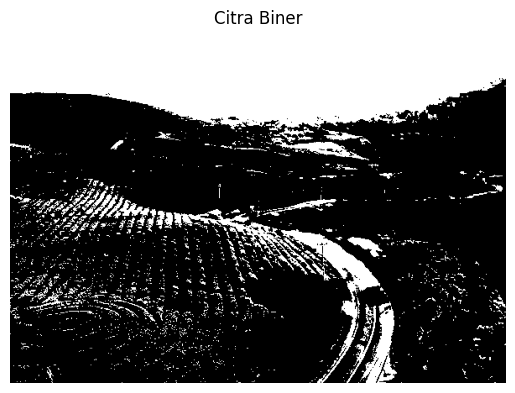

In [14]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

T = 128

binary = np.zeros_like(img_gray)

M, N = img_gray.shape

for i in range(M):
    for j in range(N):
        if img_gray[i,j] < T:
            binary[i,j] = 0
        else:
            binary[i,j] = 255

plt.imshow(binary, cmap='gray')
plt.title("Citra Biner")
plt.axis('off')

Di atas, citra dikonversi ke grayscale, kemudian dilakukan proses thresholding dengan nilai ambang 128. Setiap piksel dengan intensitas di bawah 128 diubah menjadi 0 (hitam), sedangkan yang sama atau di atas 128 diubah menjadi 255 (putih), sehingga menghasilkan citra biner yang ditampilkan dalam skala abu-abu.

(np.float64(-0.5), np.float64(590.5), np.float64(418.5), np.float64(-0.5))

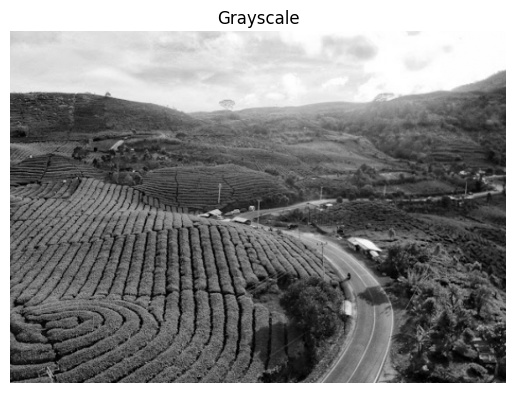

In [36]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
M, N = img_gray.shape

result = np.zeros((M,N), dtype=np.uint8)

for i in range(M):
    for j in range(N):
        value = int(img_gray[i,j])

        if value > 255:
            value = 255
        elif value < 0:
            value = 0

        result[i,j] = value

plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

Citra dikonversi menjadi grayscale, kemudian setiap nilai piksel diproses melalui perulangan dan disalin ke array baru dengan tetap memastikan nilainya berada dalam rentang 0–255 melalui proses pengecekan batas (clipping). Hasilnya kemudian ditampilkan sebagai citra grayscale menggunakan colormap abu-abu.

(np.float64(-0.5), np.float64(590.5), np.float64(418.5), np.float64(-0.5))

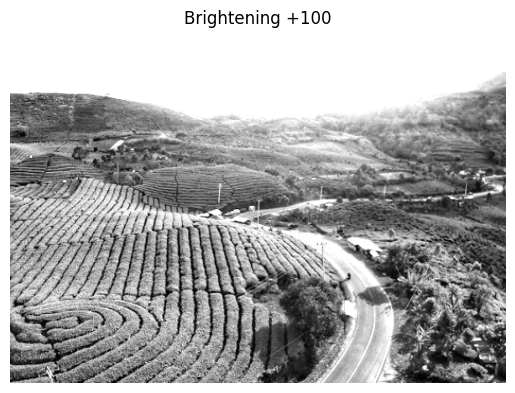

In [34]:
c = 100

M, N = img_gray.shape
bright = np.zeros((M,N), dtype=np.uint8)

for i in range(M):
    for j in range(N):
        value = int(img_gray[i,j]) + c

        if value > 255:
            value = 255
        elif value < 0:
            value = 0

        bright[i,j] = value

plt.imshow(bright, cmap='gray')
plt.title("Brightening +100")
plt.axis('off')

Setelah grayscale, dilakukan operasi penjumlahan citra dengan skalar sebesar 100 untuk meningkatkan kecerahan. Setiap piksel pada citra grayscale ditambahkan dengan nilai konstanta tersebut melalui perulangan, kemudian dilakukan proses clipping agar nilai tetap berada pada rentang 0–255. Hasilnya disimpan dalam array baru dan ditampilkan sebagai citra yang lebih terang.

(np.float64(-0.5), np.float64(590.5), np.float64(418.5), np.float64(-0.5))

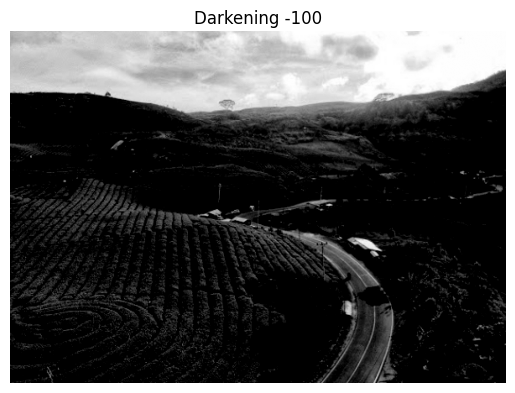

In [35]:
c = 100

dark = np.zeros((M,N), dtype=np.uint8)

for i in range(M):
    for j in range(N):
        value = int(img_gray[i,j]) - c

        if value > 255:
            value = 255
        elif value < 0:
            value = 0

        dark[i,j] = value

plt.imshow(dark, cmap='gray')
plt.title("Darkening -100")
plt.axis('off')

Dilakukan juga operasi pengurangan citra dengan skalar sebesar 100 untuk mengurangi kecerahan sehingga gambar menjadi lebih gelap. Setiap piksel pada citra grayscale dikurangi dengan nilai konstanta tersebut melalui perulangan, kemudian dilakukan proses clipping agar nilai tetap berada pada rentang 0–255. Hasilnya disimpan dalam array baru dan ditampilkan sebagai citra yang lebih gelap.

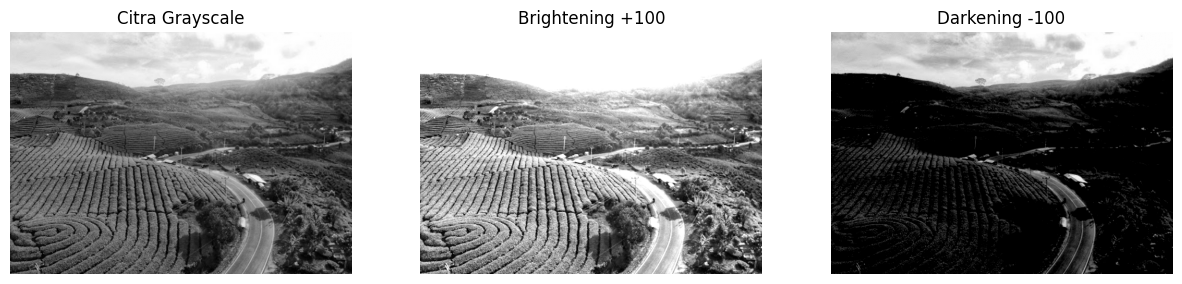

In [38]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Citra Grayscale")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(bright, cmap='gray')
plt.title("Brightening +100")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(dark, cmap='gray')
plt.title("Darkening -100")
plt.axis('off')

plt.show()

Setelah itu, ditampilkan tiga citra dalam satu tampilan secara berdampingan, yaitu citra grayscale asli, citra hasil penjumlahan skalar sebesar 100 (lebih terang), dan citra hasil pengurangan skalar sebesar 100 (lebih gelap). Fungsi plt.figure() mengatur ukuran tampilan, sedangkan plt.subplot() membagi area menjadi tiga bagian. Masing-masing citra ditampilkan menggunakan imshow() dengan colormap abu-abu, diberi judul, dan sumbu koordinat disembunyikan agar visualisasi lebih rapi.

Jika ingin langsung menjumlahkan/mengurangi citra dengan skalar langsung dari citra asli, bisa mengetikkan kode seperti berikut. Langkah-langkahnya hampir persis secara keseluruhan, hanya tidak melakukan proses citra asli ke citra grayscale saja.

(np.float64(-0.5), np.float64(590.5), np.float64(418.5), np.float64(-0.5))

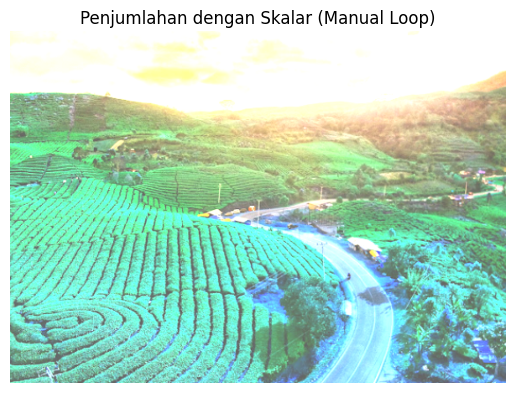

In [33]:
c = 100

# Ambil ukuran citra
M, N, C = img.shape   # C = channel (RGB)

# Buat array kosong untuk hasil
result = np.zeros((M, N, C), dtype=np.uint8)

# Loop sesuai pseudocode
for i in range(M):
    for j in range(N):
        for k in range(C):  # untuk RGB
            value = int(img[i,j,k]) + c

            # Clipping
            if value > 255:
                value = 255
            elif value < 0:
                value = 0

            result[i,j,k] = value

plt.imshow(result)
plt.title("Penjumlahan dengan Skalar (Manual Loop)")
plt.axis('off')

(np.float64(-0.5), np.float64(590.5), np.float64(418.5), np.float64(-0.5))

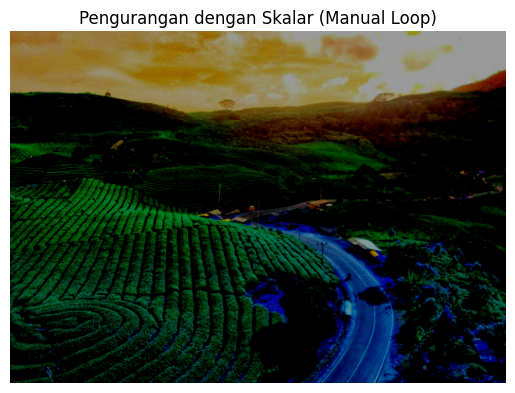

In [24]:
c = 100

result2 = np.zeros((M, N, C), dtype=np.uint8)

for i in range(M):
    for j in range(N):
        for k in range(C):
            value = int(img[i,j,k]) - c

            if value > 255:
                value = 255
            elif value < 0:
                value = 0

            result2[i,j,k] = value

plt.imshow(result2)
plt.title("Pengurangan dengan Skalar (Manual Loop)")
plt.axis('off')

# PENJUMLAHAN CITRA DENGAN SKALAR c=50 (Brightening) Langsung dengan Python

Jika ingin melakukan operasi langsung dengan python tanpa banyak perulangan, bisa mengetikkan kode seperti di bawah ini.

(np.float64(-0.5), np.float64(590.5), np.float64(418.5), np.float64(-0.5))

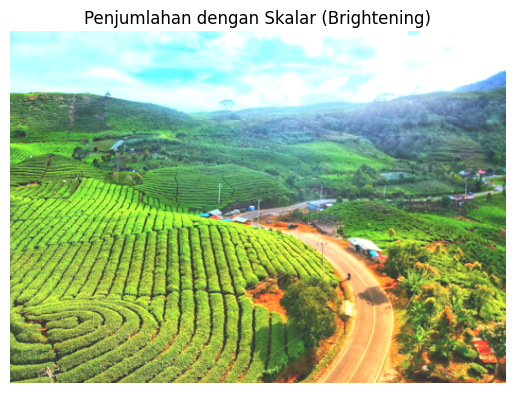

In [5]:
c = 50

# Konversi ke tipe int16 supaya tidak overflow
bright_img = img.astype(np.int16) + c

# Clipping supaya tetap di range 0–255
bright_img = np.clip(bright_img, 0, 255)

# Kembalikan ke uint8
bright_img = bright_img.astype(np.uint8)

# Konversi warna untuk ditampilkan
bright_img_rgb = cv2.cvtColor(bright_img, cv2.COLOR_BGR2RGB)

plt.imshow(bright_img_rgb)
plt.title("Penjumlahan dengan Skalar (Brightening)")
plt.axis('off')

Kode di atas melakukan operasi penjumlahan citra berwarna dengan skalar sebesar 50 untuk meningkatkan kecerahan. Citra terlebih dahulu dikonversi ke tipe data int16 untuk mencegah terjadinya overflow saat penambahan nilai piksel. Setelah itu, dilakukan proses clipping menggunakan np.clip() agar nilai intensitas tetap berada pada rentang 0–255, kemudian dikembalikan ke tipe uint8. Sebelum ditampilkan, citra dikonversi dari format BGR ke RGB agar warna sesuai saat divisualisasikan menggunakan Matplotlib.

(np.float64(-0.5), np.float64(590.5), np.float64(418.5), np.float64(-0.5))

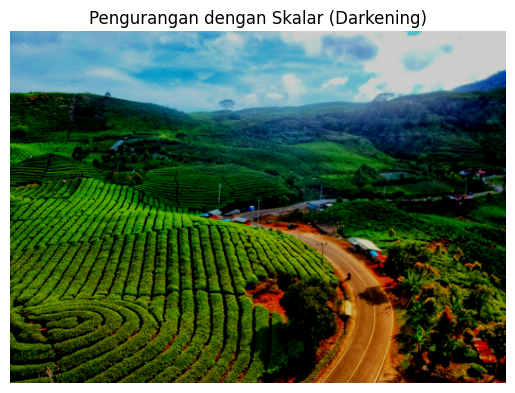

In [6]:
c = 50

dark_img = img.astype(np.int16) - c
dark_img = np.clip(dark_img, 0, 255)
dark_img = dark_img.astype(np.uint8)

dark_img_rgb = cv2.cvtColor(dark_img, cv2.COLOR_BGR2RGB)

plt.imshow(dark_img_rgb)
plt.title("Pengurangan dengan Skalar (Darkening)")
plt.axis('off')

Kode di atas melakukan operasi pengurangan citra berwarna dengan skalar sebesar 50 untuk mengurangi kecerahan (darkening). Citra terlebih dahulu dikonversi ke tipe data int16 agar tidak terjadi underflow saat nilai piksel dikurangi. Selanjutnya, dilakukan clipping menggunakan np.clip() untuk memastikan nilai tetap berada dalam rentang 0–255, kemudian dikembalikan ke tipe uint8. Sebelum ditampilkan, citra dikonversi dari format BGR ke RGB agar warna tampil dengan benar pada visualisasi.

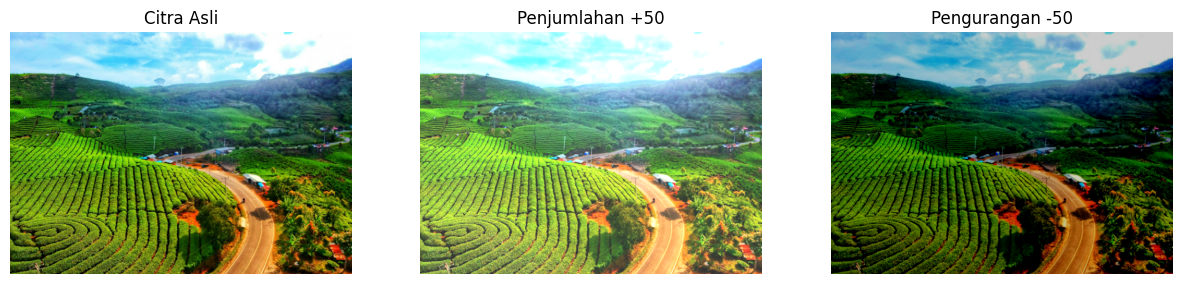

In [7]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(bright_img_rgb)
plt.title("Penjumlahan +50")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(dark_img_rgb)
plt.title("Pengurangan -50")
plt.axis('off')

plt.show()

Ditampilkan tiga citra secara berdampingan dalam satu tampilan, yaitu citra asli, citra hasil penjumlahan skalar sebesar 50 (lebih terang), dan citra hasil pengurangan skalar sebesar 50 (lebih gelap). Fungsi plt.figure() mengatur ukuran tampilan, sedangkan plt.subplot() membagi area menjadi tiga bagian. Setiap citra ditampilkan menggunakan imshow(), diberi judul sesuai operasinya, dan sumbu koordinat disembunyikan agar tampilan lebih rapi dan mudah dibandingkan.